In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
import matplotlib 
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from matplotlib import font_manager, rc
path = "c:/Windows/Fonts/malgun.ttf"
if platform.system() == 'Darwin':
    rc('font', family='AppleGothic')
elif platform.system() == 'Windows':
    font_name = font_manager.FontProperties(fname=path).get_name()
    rc('font', family=font_name)
else:
    print('Unknown system... sorry~~~~')

In [44]:
!pip install dython

In [4]:
data = pd.read_excel("C:/Users/PC/Desktop/프로젝트/(보안)산단공 관할산단 산업재해 자료.xlsx", sheet_name = "재해자명단")
data.head()

,시도명,관리기관,단지명,입주일,최초등록일,기준년월,노동지청,행정구역,대업종,중업종,...,직종(중),직종(소),재해발생일,요양승인일,사망승인일,근로손실일수,요양기간,근속기간,성별,연령
0,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20180604.0,NaN,202012,서울관악,서울,기타의사업,도소매·음식·숙박업,...,판매 및 고객서비스 관리직,판매 및 운송 관리자,20191219,20200708,NaN,147,91일 ~ 180일,1년 ~ 2년 미만,남,30세 ~ 34세
1,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20100202.0,20210419.0,201812,서울관악,서울,기타의사업,도소매·음식·숙박업,...,경영·금융 전문가 및 관련직,기술영업 및 중개 관련종사자,20180321,20180906,NaN,221,6개월 ~ 1년미만,5년 ~ 10년 미만,남,50세 ~ 54세
2,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,NaN,19970930.0,201912,서울관악,서울,제조업,출판·인쇄·제본또는인쇄물가공업,...,전기 및 전자 관련 기계조작직,전기·전자 부품 및 제품 제조장치 조작원,20190112,20190404,NaN,113,91일 ~ 180일,4년 ~ 5년 미만,남,55세 ~ 59세
3,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20060119.0,20060703.0,201912,서울관악,서울,제조업,섬유및섬유제품제조업,...,섬유·의복 및 가죽 관련 기능직,섬유 및 가죽 관련 기능 종사자,20181212,20190122,NaN,42,29일 ~ 90일,10년 ~ 20년 미만,여,50세 ~ 54세
4,서울특별시,한국산업단지공단 서울지역본부,서울디지털국가산업단지,20140312.0,20140530.0,201812,서울관악,서울,제조업,섬유및섬유제품제조업,...,섬유 및 신발 관련 기계조작직,섬유제조 및 가공기계조작원,20181007,20181026,NaN,149,91일 ~ 180일,1년 ~ 2년 미만,남,60세 ~ 64세


In [139]:
data.shape

(19825, 29)

In [140]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 29 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   시도명     19825 non-null  object 
 1   관리기관    19825 non-null  object 
 2   단지명     19825 non-null  object 
 3   입주일     19313 non-null  float64
 4   최초등록일   16449 non-null  float64
 5   기준년월    19825 non-null  int64  
 6   노동지청    19825 non-null  object 
 7   행정구역    19825 non-null  object 
 8   대업종     19825 non-null  object 
 9   중업종     19825 non-null  object 
 10  소업종     19825 non-null  object 
 11  근로자수    19825 non-null  int64  
 12  재해자구분   19825 non-null  object 
 13  발생형태    19825 non-null  object 
 14  직업병(대)  19825 non-null  object 
 15  직업병(중)  19825 non-null  object 
 16  직업병(소)  19825 non-null  object 
 17  직업병(세)  19825 non-null  object 
 18  직종(대)   19825 non-null  object 
 19  직종(중)   19825 non-null  object 
 20  직종(소)   19825 non-null  object 
 21  재해발생일   19825 non-null  int64  
 22

In [141]:
data.isnull().sum()

시도명           0
관리기관          0
단지명           0
입주일         512
최초등록일      3376
기준년월          0
노동지청          0
행정구역          0
대업종           0
중업종           0
소업종           0
근로자수          0
재해자구분         0
발생형태          0
직업병(대)        0
직업병(중)        0
직업병(소)        0
직업병(세)        0
직종(대)         0
직종(중)         0
직종(소)         0
재해발생일         0
요양승인일         0
사망승인일     19514
근로손실일수        0
요양기간          0
근속기간          0
성별            0
연령            0
dtype: int64

In [5]:
data.발생형태.value_counts()

끼임              4498
작업관련질병(뇌심 등)    3713
넘어짐             1920
직업병(진폐 제외)      1588
부딪힘             1524
물체에 맞음          1428
떨어짐             1199
절단·베임·찔림        1135
불균형 및 무리한동작      770
이상온도 접촉          443
깔림·뒤집힘           385
사업장외 교통사고        310
체육행사 등의 사고       274
화학물질누출·접촉        162
사업장내 교통사고        110
폭발·파열             87
감전                75
화재                57
진폐                49
폭력행위              40
무너짐               39
기타                 5
동물상해               5
분류불능               4
산소결핍               3
빠짐ㆍ익사              2
Name: 발생형태, dtype: int64

In [147]:
df = data.drop(columns = ["사망승인일" , "기준년월", "입주일", "최초등록일", "재해발생일", "요양승인일", "직업병(대)", "직업병(중)", "직업병(소)", "직업병(세)"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   시도명     19825 non-null  object
 1   관리기관    19825 non-null  object
 2   단지명     19825 non-null  object
 3   노동지청    19825 non-null  object
 4   행정구역    19825 non-null  object
 5   대업종     19825 non-null  object
 6   중업종     19825 non-null  object
 7   소업종     19825 non-null  object
 8   근로자수    19825 non-null  int64 
 9   재해자구분   19825 non-null  object
 10  발생형태    19825 non-null  object
 11  직종(대)   19825 non-null  object
 12  직종(중)   19825 non-null  object
 13  직종(소)   19825 non-null  object
 14  근로손실일수  19825 non-null  int64 
 15  요양기간    19825 non-null  object
 16  근속기간    19825 non-null  object
 17  성별      19825 non-null  object
 18  연령      19825 non-null  object
dtypes: int64(2), object(17)
memory usage: 2.9+ MB


In [168]:
df.columns

Index(['시도명', '관리기관', '단지명', '노동지청', '행정구역', '대업종', '중업종', '소업종', '근로자수',
       '재해자구분', '발생형태', '직종(대)', '직종(중)', '직종(소)', '근로손실일수', '요양기간', '근속기간',
       '성별', '연령'],
      dtype='object')

In [179]:
df.rename(columns = {'직종(대)':'직종대', '직종(중)':'직종중', '직종(소)':'직종소'}, inplace = True)

In [180]:
df.head()

,시도명,관리기관,단지명,노동지청,행정구역,대업종,중업종,소업종,근로자수,재해자구분,발생형태,직종대,직종중,직종소,근로손실일수,요양기간,근속기간,성별,연령
0,7,15,25,10,7,2,7,54,7,1,21,관리자,판매 및 고객서비스 관리직,판매 및 운송 관리자,147,7,3,0,2
1,7,15,25,10,7,2,7,54,7,1,21,전문가 및 관련 종사자,경영·금융 전문가 및 관련직,기술영업 및 중개 관련종사자,221,5,12,0,6
2,7,15,25,10,7,6,21,114,4,1,4,장치ㆍ기계 조작 및 조립 종사자,전기 및 전자 관련 기계조작직,전기·전자 부품 및 제품 제조장치 조작원,113,7,10,0,7
3,7,15,25,10,7,6,11,111,2,1,4,기능원 및 관련 기능 종사자,섬유·의복 및 가죽 관련 기능직,섬유 및 가죽 관련 기능 종사자,42,2,0,1,6
4,7,15,25,10,7,6,11,141,4,1,3,장치ㆍ기계 조작 및 조립 종사자,섬유 및 신발 관련 기계조작직,섬유제조 및 가공기계조작원,149,7,3,0,8


In [196]:
df.시도명 = le.fit_transform(df["시도명"])
df.관리기관 = le.fit_transform(df["관리기관"])
df.단지명 = le.fit_transform(df["단지명"])
df.노동지청 = le.fit_transform(df["노동지청"])
df.행정구역 = le.fit_transform(df["행정구역"])
df.대업종 = le.fit_transform(df["대업종"])
df.중업종 = le.fit_transform(df["중업종"])
df.소업종 = le.fit_transform(df["소업종"])
df.재해자구분 = le.fit_transform(df["재해자구분"])
df.발생형태 = le.fit_transform(df["발생형태"])
df.직종대 = le.fit_transform(df["직종대"])
df.직종중 = le.fit_transform(df["직종중"])
df.직종소 = le.fit_transform(df["직종소"])
df.근로손실일수 = le.fit_transform(df["근로손실일수"])
df.요양기간 = le.fit_transform(df["요양기간"])
df.근속기간 = le.fit_transform(df["근속기간"])
df.성별 = le.fit_transform(df["성별"])
df.연령 = le.fit_transform(df["연령"])
df.head()

,시도명,관리기관,단지명,노동지청,행정구역,대업종,중업종,소업종,근로자수,재해자구분,발생형태,직종대,직종중,직종소,근로손실일수,요양기간,근속기간,성별,연령
0,7,15,25,10,7,2,7,54,7,1,21,1,50,122,147,7,3,0,2
1,7,15,25,10,7,2,7,54,7,1,21,9,8,32,221,5,12,0,6
2,7,15,25,10,7,6,21,114,4,1,4,8,43,105,113,7,10,0,7
3,7,15,25,10,7,6,11,111,2,1,4,2,32,69,42,2,0,1,6
4,7,15,25,10,7,6,11,141,4,1,3,8,31,70,149,7,3,0,8


In [197]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   시도명     19825 non-null  int64
 1   관리기관    19825 non-null  int64
 2   단지명     19825 non-null  int64
 3   노동지청    19825 non-null  int64
 4   행정구역    19825 non-null  int64
 5   대업종     19825 non-null  int64
 6   중업종     19825 non-null  int64
 7   소업종     19825 non-null  int64
 8   근로자수    19825 non-null  int64
 9   재해자구분   19825 non-null  int64
 10  발생형태    19825 non-null  int64
 11  직종대     19825 non-null  int64
 12  직종중     19825 non-null  int64
 13  직종소     19825 non-null  int64
 14  근로손실일수  19825 non-null  int64
 15  요양기간    19825 non-null  int64
 16  근속기간    19825 non-null  int64
 17  성별      19825 non-null  int64
 18  연령      19825 non-null  int64
dtypes: int64(19)
memory usage: 2.9 MB


In [198]:
x = df.drop(columns = ["발생형태"])
y = pd.DataFrame(df["발생형태"])

C:\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:214: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:183: RuntimeWarning: Glyph 8722 missing from current font.
  font.set_text(s, 0, flags=flags)


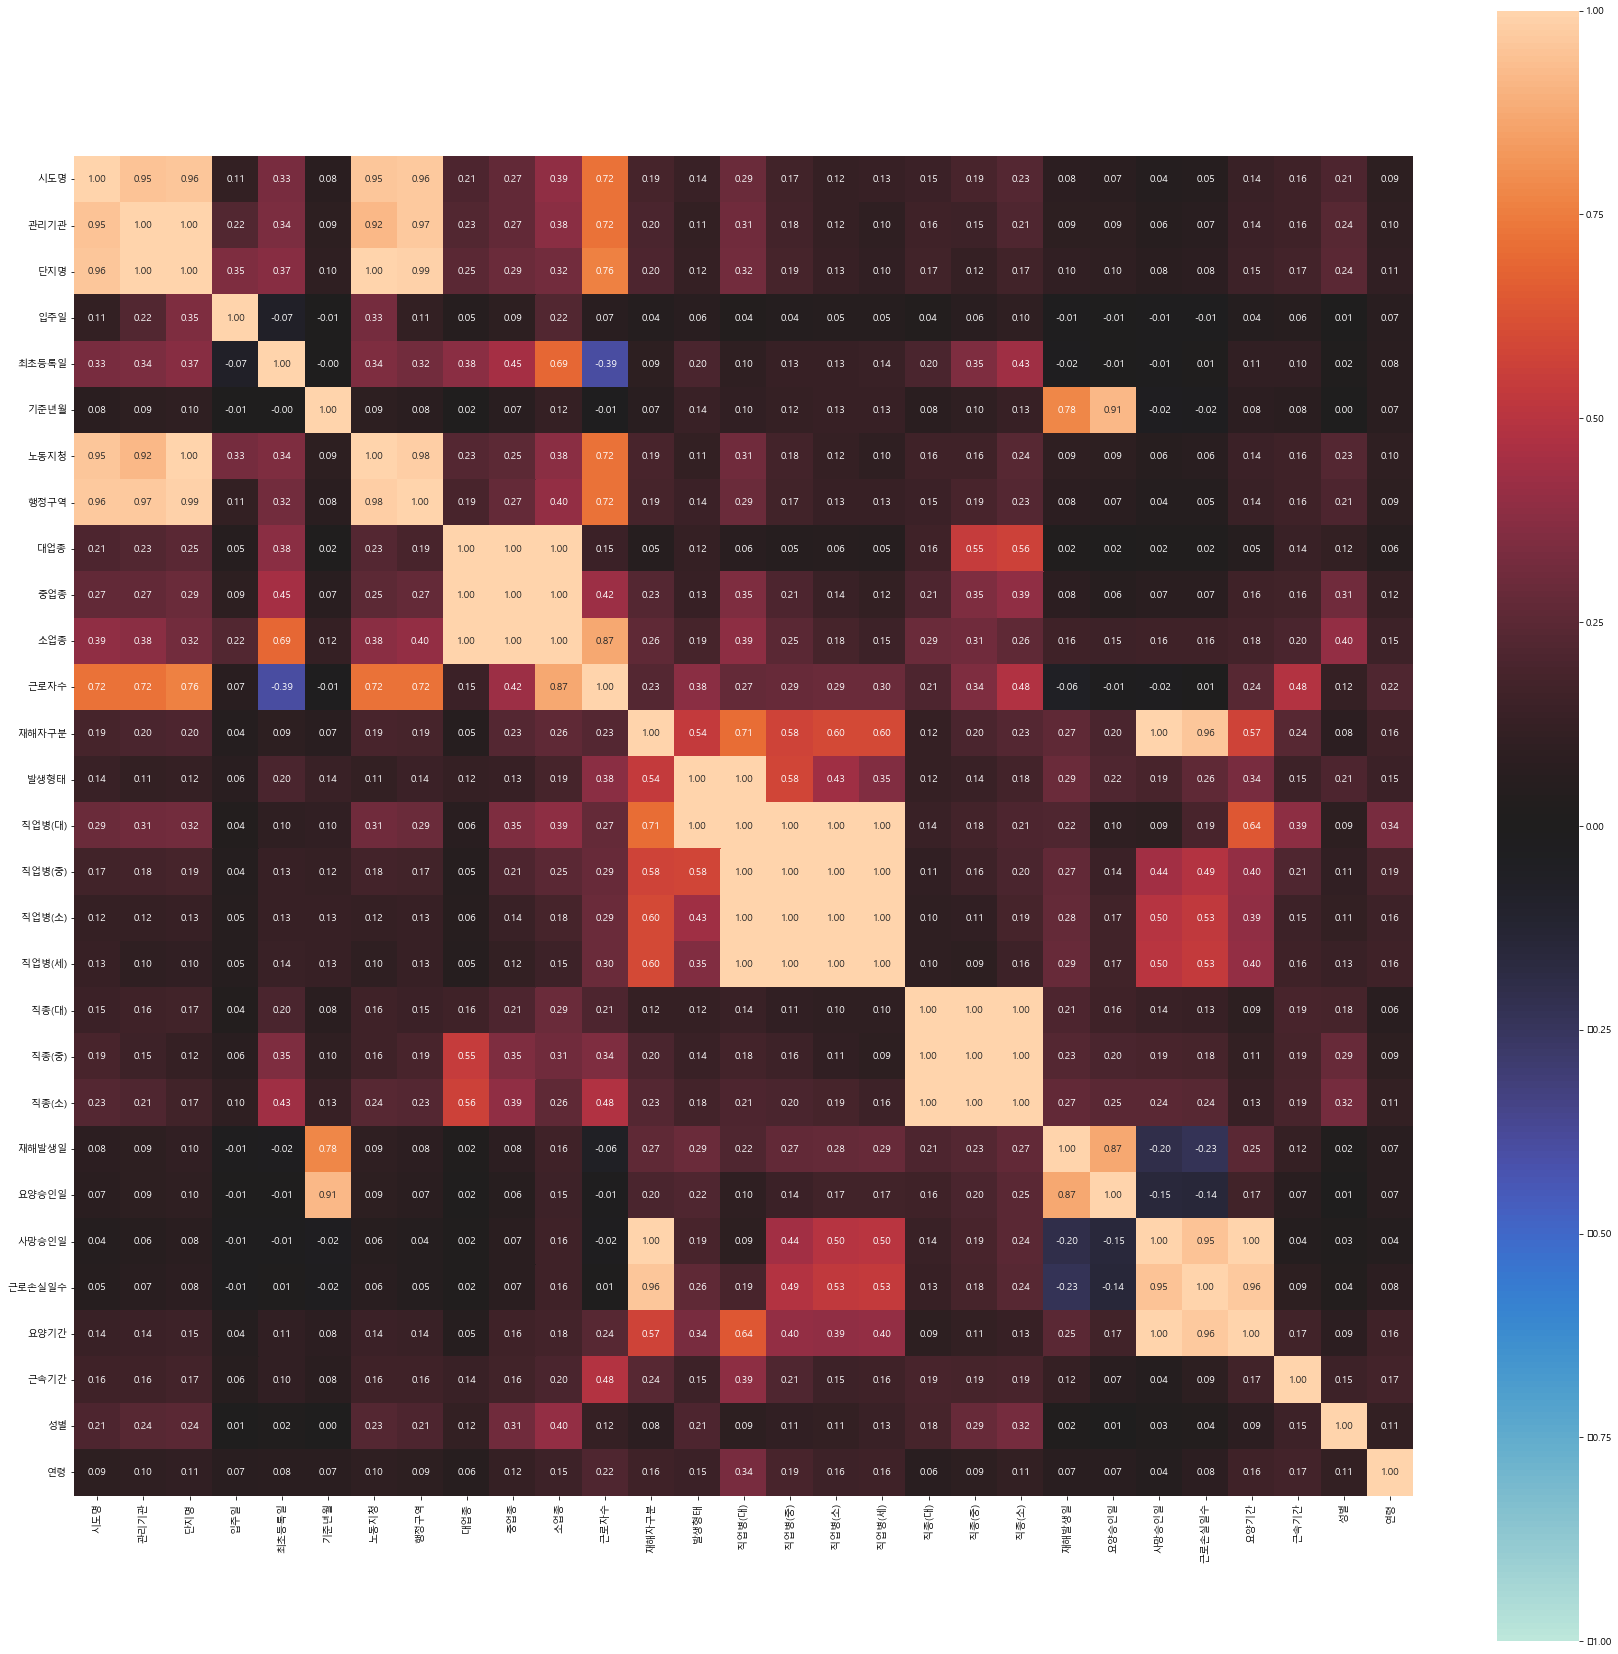

{'corr':              시도명      관리기관       단지명       입주일     최초등록일      기준년월      노동지청  \
 시도명     1.000000  0.948978  0.960329  0.113331  0.329067  0.076073  0.954612   
 관리기관    0.948978  1.000000  0.999219  0.224119  0.342746  0.091346  0.919312   
 단지명     0.960329  0.999219  1.000000  0.346405  0.367761  0.101309  0.999242   
 입주일     0.113331  0.224119  0.346405  1.000000 -0.072832 -0.006943  0.327560   
 최초등록일   0.329067  0.342746  0.367761 -0.072832  1.000000 -0.004810  0.344321   
 기준년월    0.076073  0.091346  0.101309 -0.006943 -0.004810  1.000000  0.091026   
 노동지청    0.954612  0.919312  0.999242  0.327560  0.344321  0.091026  1.000000   
 행정구역    0.964373  0.965772  0.991670  0.113204  0.315954  0.076688  0.981106   
 대업종     0.209320  0.225655  0.247976  0.049034  0.375241  0.015339  0.233755   
 중업종     0.270379  0.267196  0.289437  0.090883  0.450461  0.065228  0.253367   
 소업종     0.394947  0.379837  0.316392  0.219888  0.692735  0.121144  0.376853   
 근로자수    0.720471  0

In [49]:
from dython.nominal import associations
associations(data, figsize=(30, 30))

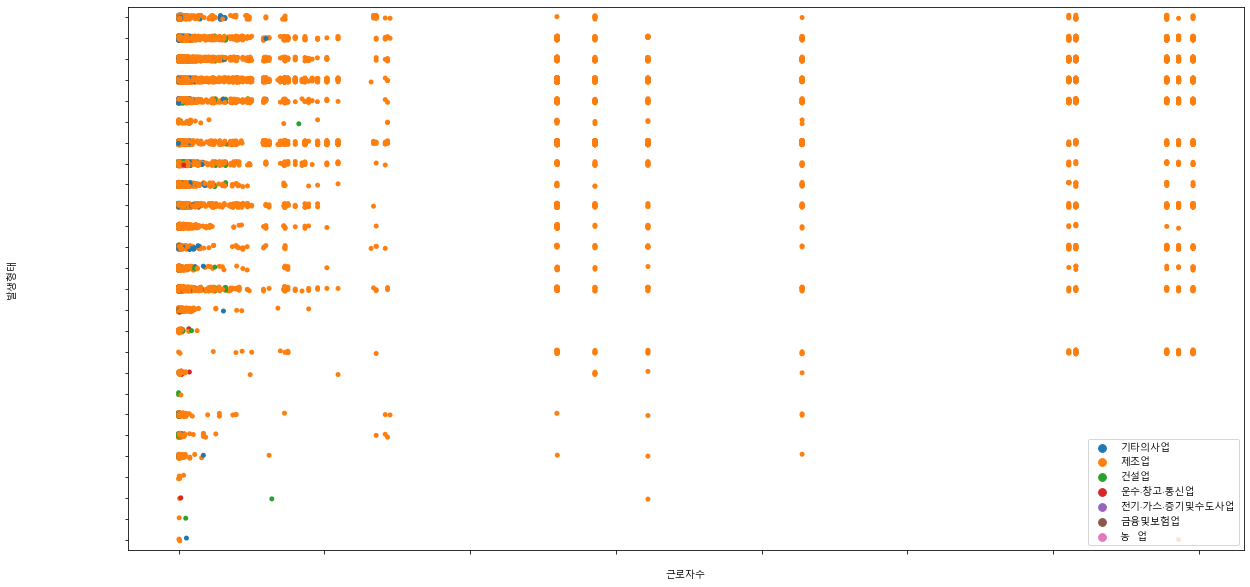

In [39]:
plt.figure(figsize = (20, 10))
ax1 = sns.stripplot(x = "근로자수", y = "발생형태", data = data, hue = "대업종")
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')
ax1.legend()

In [ ]:
data["단지명"].value_counts()

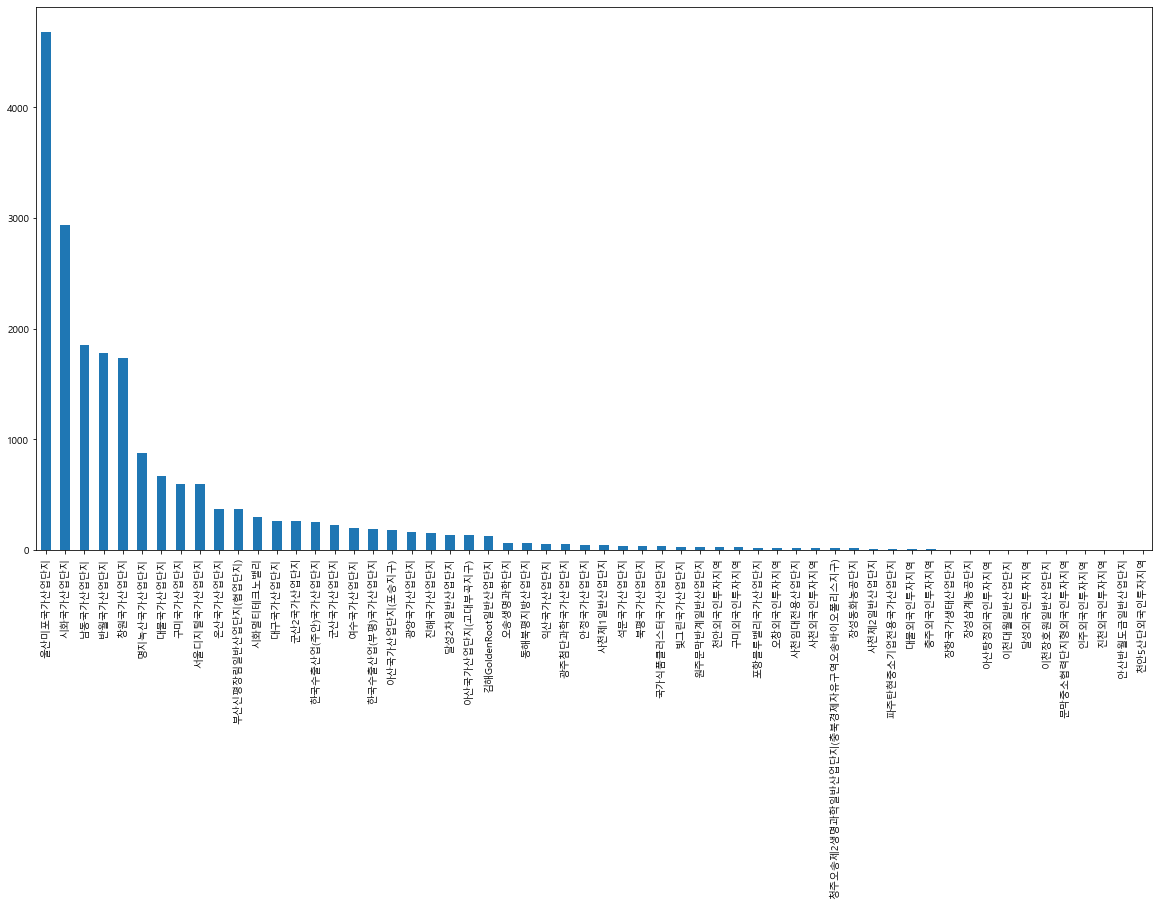

In [10]:
plt.figure(figsize = (20, 10))
data["단지명"].value_counts().plot(kind = "bar")

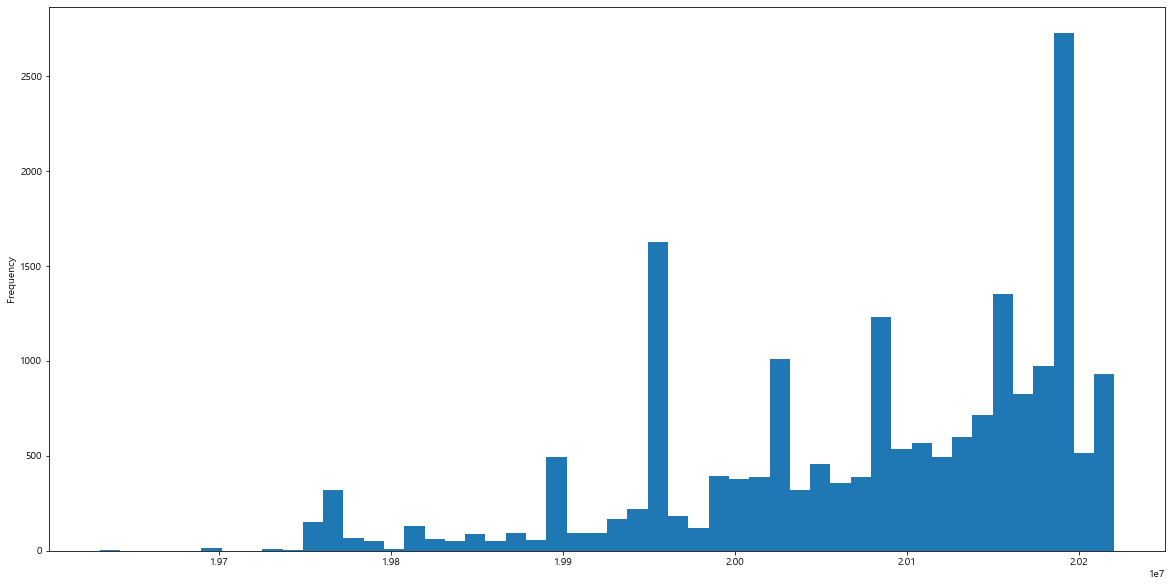

In [11]:
plt.figure(figsize = (20, 10))
data["입주일"].plot(kind = "hist", bins = 50)

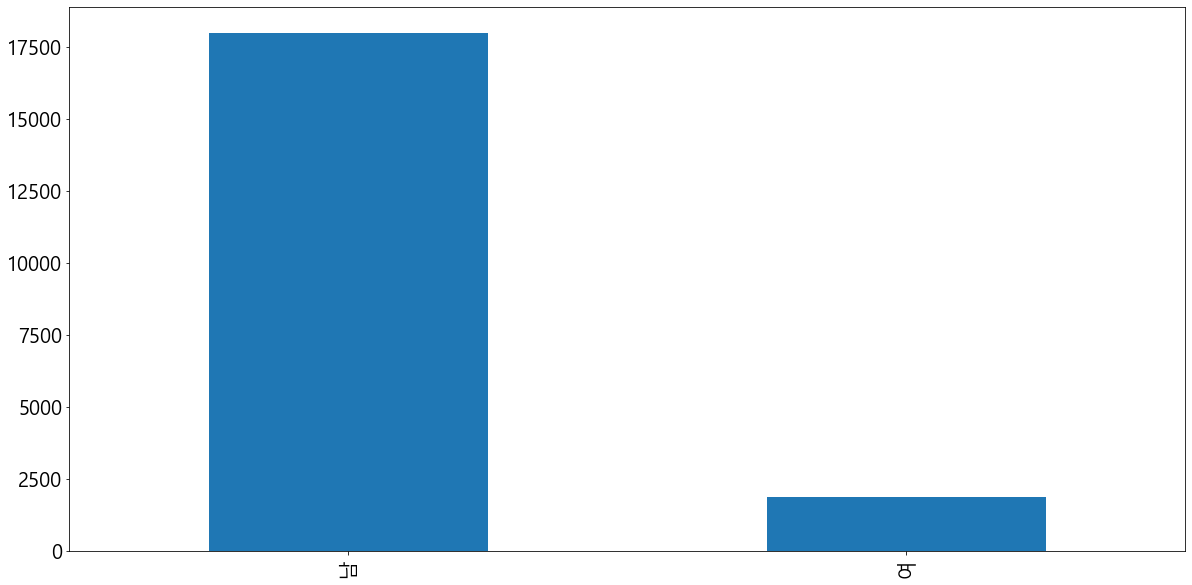

In [67]:
plt.figure(figsize = (20, 10))
data["성별"].value_counts().plot(kind = "bar")

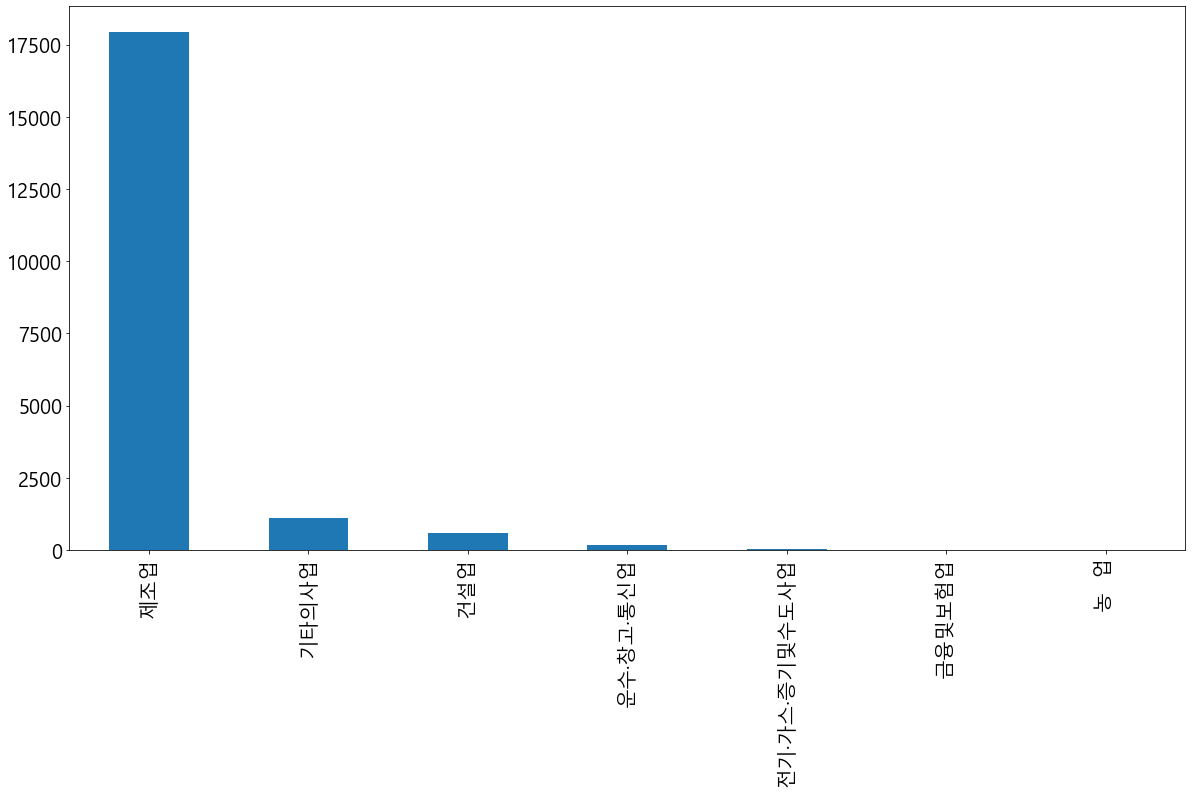

In [68]:
plt.figure(figsize = (20, 10))
data["대업종"].value_counts().plot(kind = "bar")

In [14]:
data.행정구역.value_counts()

경기    5275
울산    5049
인천    2295
경남    2162
부산    1248
전남    1069
경북     668
서울     595
전북     585
대구     390
충남     217
강원     127
충북     114
광주      31
Name: 행정구역, dtype: int64

In [15]:
data.재해발생일.value_counts()

20200506    28
20200626    28
20200824    28
20180821    27
20190828    27
            ..
20150807     1
20160924     1
20150615     1
20151229     1
19910704     1
Name: 재해발생일, Length: 2189, dtype: int64

In [16]:
data.대업종.value_counts()

제조업              17925
기타의사업             1098
건설업                584
운수·창고·통신업          190
전기·가스·증기및수도사업       26
금융및보험업               1
농  업                 1
Name: 대업종, dtype: int64

In [17]:
data.연령.value_counts()

60세 ~ 64세    3146
55세 ~ 59세    2881
50세 ~ 54세    2661
40세 ~ 44세    2329
45세 ~ 49세    2289
35세 ~ 39세    2012
30세 ~ 34세    1539
25세 ~ 29세    1299
65세 ~ 69세     734
18세 ~ 24세     589
70세 ~ 74세     244
75세 ~ 79세      85
80세 이상         17
Name: 연령, dtype: int64

In [18]:
data.재해자구분.value_counts()

사고부상자       14344
질병이환자        5170
질병사망자         180
업무상사고사망자      105
그외사고사망자        26
Name: 재해자구분, dtype: int64

In [19]:
data.발생형태.value_counts()

끼임              4498
작업관련질병(뇌심 등)    3713
넘어짐             1920
직업병(진폐 제외)      1588
부딪힘             1524
물체에 맞음          1428
떨어짐             1199
절단·베임·찔림        1135
불균형 및 무리한동작      770
이상온도 접촉          443
깔림·뒤집힘           385
사업장외 교통사고        310
체육행사 등의 사고       274
화학물질누출·접촉        162
사업장내 교통사고        110
폭발·파열             87
감전                75
화재                57
진폐                49
폭력행위              40
무너짐               39
기타                 5
동물상해               5
분류불능               4
산소결핍               3
빠짐ㆍ익사              2
Name: 발생형태, dtype: int64

In [108]:
data.columns

Index(['시도명', '관리기관', '단지명', '입주일', '최초등록일', '기준년월', '노동지청', '행정구역', '대업종',
       '중업종', '소업종', '근로자수', '재해자구분', '발생형태', '직업병(대)', '직업병(중)', '직업병(소)',
       '직업병(세)', '직종(대)', '직종(중)', '직종(소)', '재해발생일', '요양승인일', '사망승인일',
       '근로손실일수', '요양기간', '근속기간', '성별', '연령'],
      dtype='object')

In [109]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

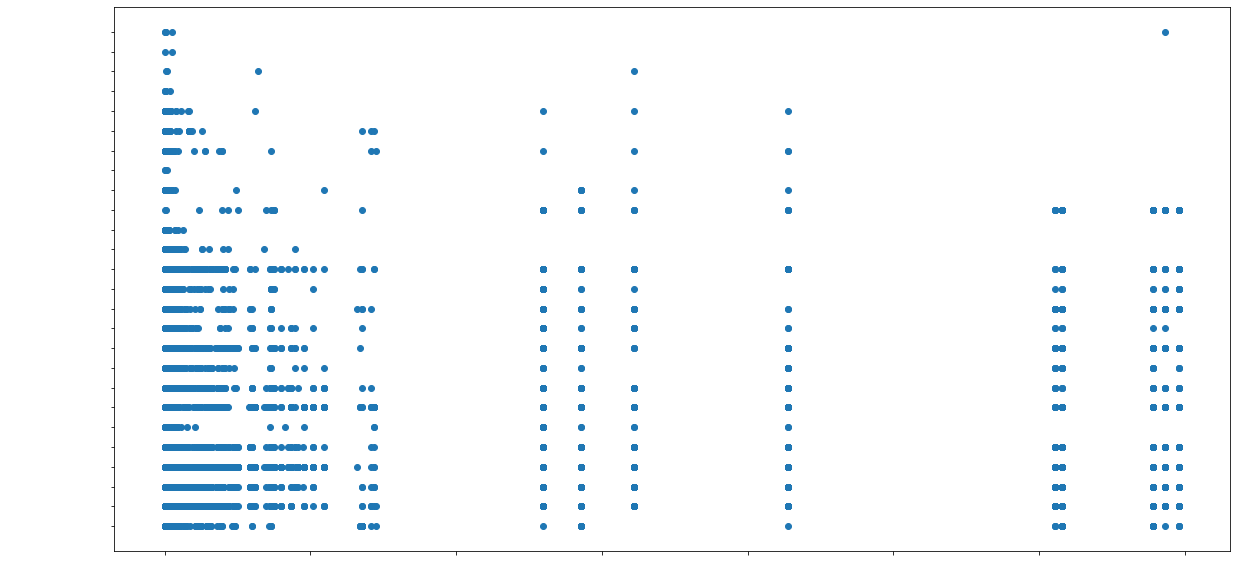

In [41]:
plt.figure(figsize = (20,10))
plt.scatter(data.근로자수, data.발생형태)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

In [76]:
data1 = pd.read_csv("C:/Users/PC/Desktop/kicox_data_cutting.csv")
data1.head()

,단지명,중업종,소업종,근로자수,발생형태,근속기간,연령
0,서울디지털국가산업단지,도소매·음식·숙박업,도소매및소비자용품수리업,7,체육행사 등의 사고,1년 ~ 2년 미만,30세 ~ 34세
1,서울디지털국가산업단지,도소매·음식·숙박업,도소매및소비자용품수리업,7,체육행사 등의 사고,5년 ~ 10년 미만,50세 ~ 54세
2,서울디지털국가산업단지,출판·인쇄·제본또는인쇄물가공업,인쇄업,4,넘어짐,4년 ~ 5년 미만,55세 ~ 59세
3,서울디지털국가산업단지,섬유및섬유제품제조업,의복및장신품등의제조업,2,넘어짐,10년 ~ 20년 미만,50세 ~ 54세
4,서울디지털국가산업단지,섬유및섬유제품제조업,직물업,4,끼임,1년 ~ 2년 미만,60세 ~ 64세


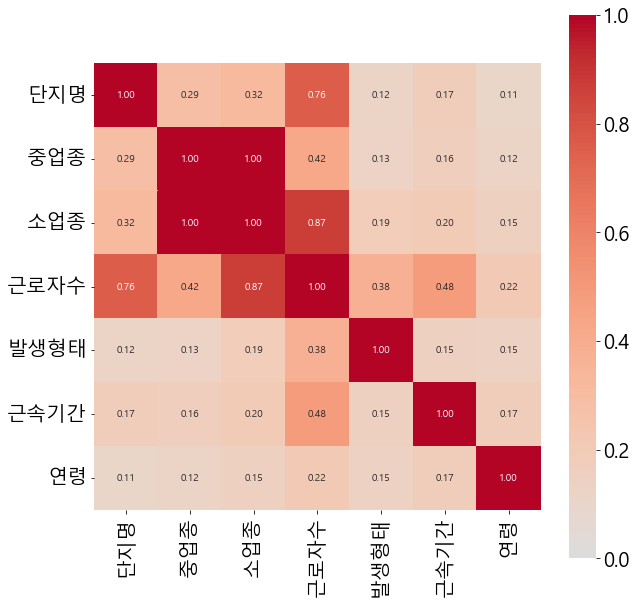

{'corr':            단지명       중업종       소업종      근로자수      발생형태      근속기간        연령
 단지명   1.000000  0.289437  0.316392  0.758860  0.120514  0.172272  0.105539
 중업종   0.289437  1.000000  0.996129  0.424009  0.129343  0.164177  0.117419
 소업종   0.316392  0.996129  1.000000  0.871709  0.185765  0.201022  0.150882
 근로자수  0.758860  0.424009  0.871709  1.000000  0.376933  0.484384  0.215996
 발생형태  0.120514  0.129343  0.185765  0.376933  1.000000  0.154795  0.147441
 근속기간  0.172272  0.164177  0.201022  0.484384  0.154795  1.000000  0.172850
 연령    0.105539  0.117419  0.150882  0.215996  0.147441  0.172850  1.000000,
 'ax': <matplotlib.axes._subplots.AxesSubplot at 0x20399585c88>}

In [77]:
from dython.nominal import associations
associations(data1, cmap = "coolwarm", figsize=(10, 10))

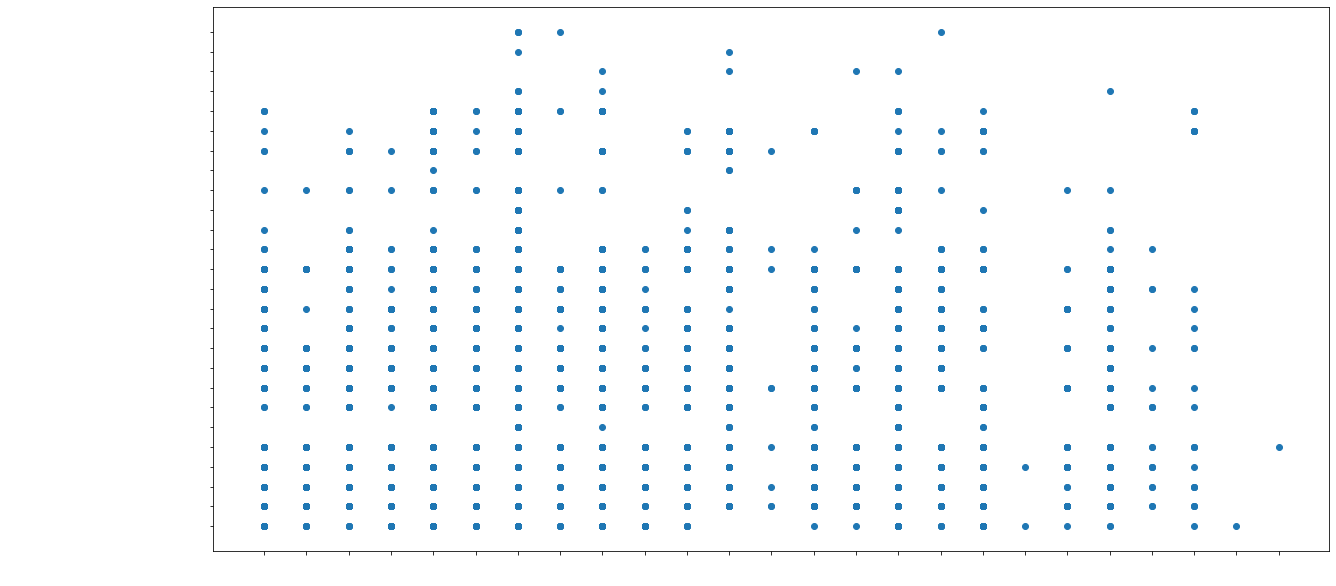

In [78]:
plt.figure(figsize = (20,10))
plt.scatter(data1.중업종, data1.발생형태)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

In [79]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   단지명     19825 non-null  object
 1   중업종     19825 non-null  object
 2   소업종     19825 non-null  object
 3   근로자수    19825 non-null  int64 
 4   발생형태    19825 non-null  object
 5   근속기간    19825 non-null  object
 6   연령      19825 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.1+ MB


feature: {} 단지명
울산미포국가산업단지                              4677
시화국가산업단지                                2934
남동국가산업단지                                1850
반월국가산업단지                                1783
창원국가산업단지                                1733
명지녹산국가산업단지                               878
대불국가산업단지                                 666
구미국가산업단지                                 601
서울디지털국가산업단지                              595
온산국가산업단지                                 372
부산신평장림일반산업단지(협업단지)                       370
시화멀티테크노밸리                                303
대구국가산업단지                                 266
군산2국가산업단지                                265
한국수출산업(주안)국가산업단지                         253
군산국가산업단지                                 229
여수국가산업단지                                 204
한국수출산업(부평)국가산업단지                         192
아산국가산업단지(포승지구)                           181
광양국가산업단지                                 168
진해국가산업단지                                 155
달성2차일반산업단지                             

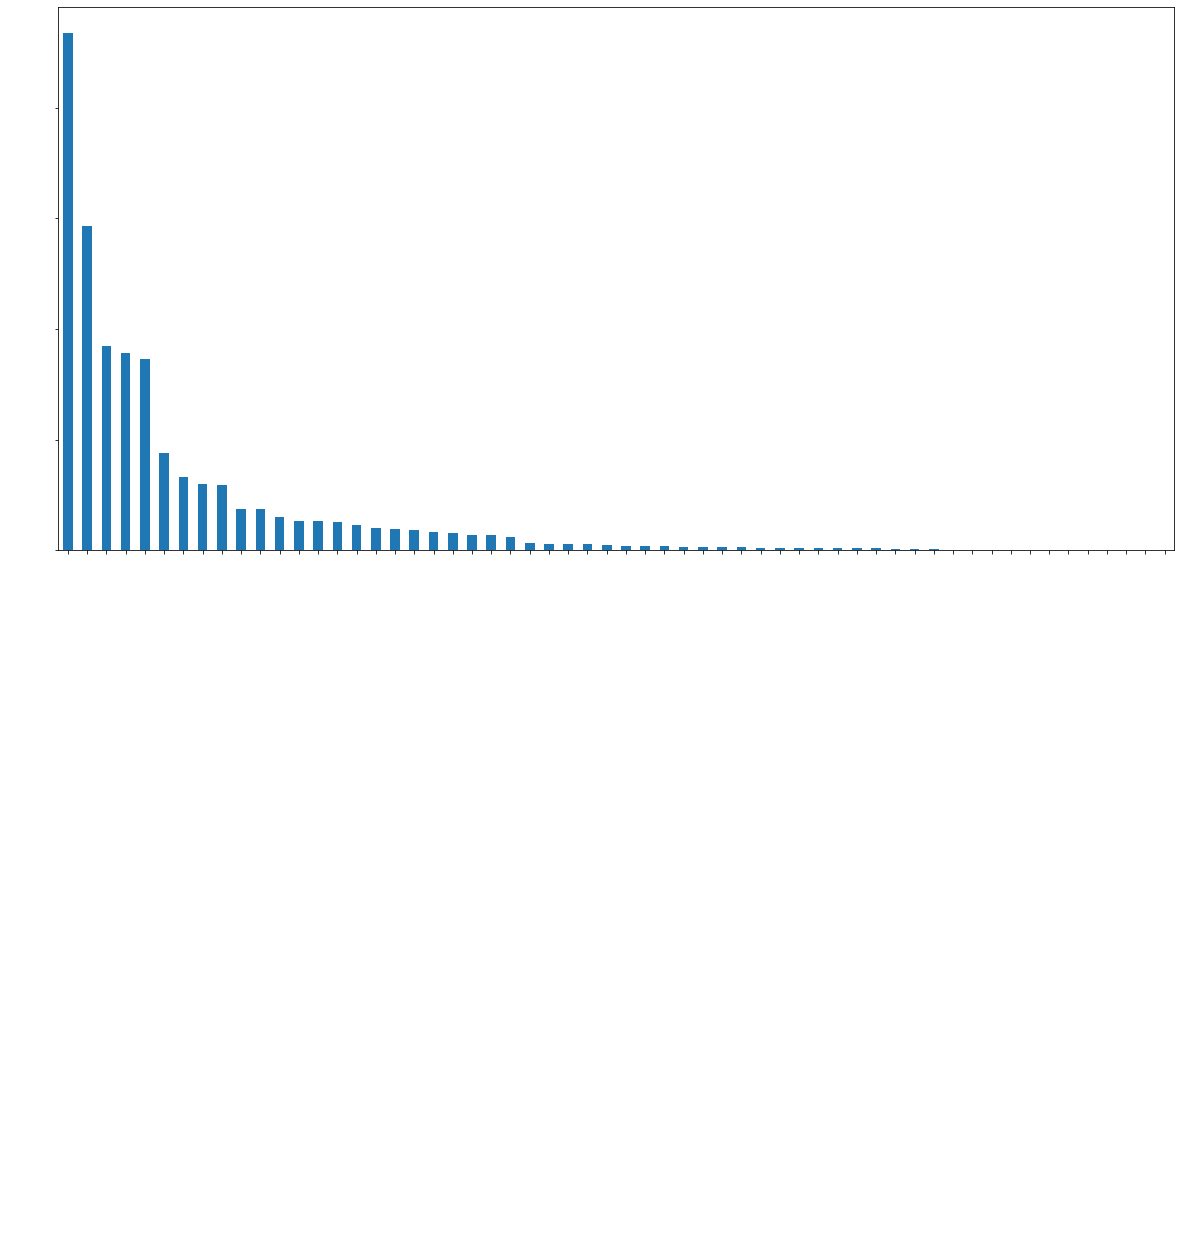

feature: {} 중업종
기계기구·금속·비금속광물제품제조업     9593
선박건조및수리업               3320
화학및고무제품제조업             1500
전기기계기구·정밀기구·전자제품제조업    1295
건설업                     584
도소매·음식·숙박업              472
식료품제조업                  443
섬유및섬유제품제조업              436
목재및종이제품제조업              430
수제품및기타제품제조업             344
의약품·화장품·연탄·석유제품제조업      289
시설관리및사업지원서비스업           211
전문·보건·교육·여가관련서비스업       169
출판·인쇄·제본또는인쇄물가공업        150
국가및지방자치단체의사업            141
철도·항공·창고·운수관련서비스업       134
금속제련업                   125
기타의각종사업                  79
육상및수상운수업                 54
전기·가스·증기및수도사업            26
해외파견자                    17
부동산업및임대업                  9
통신업                       2
금융및보험업                    1
농업                        1
Name: 중업종, dtype: int64


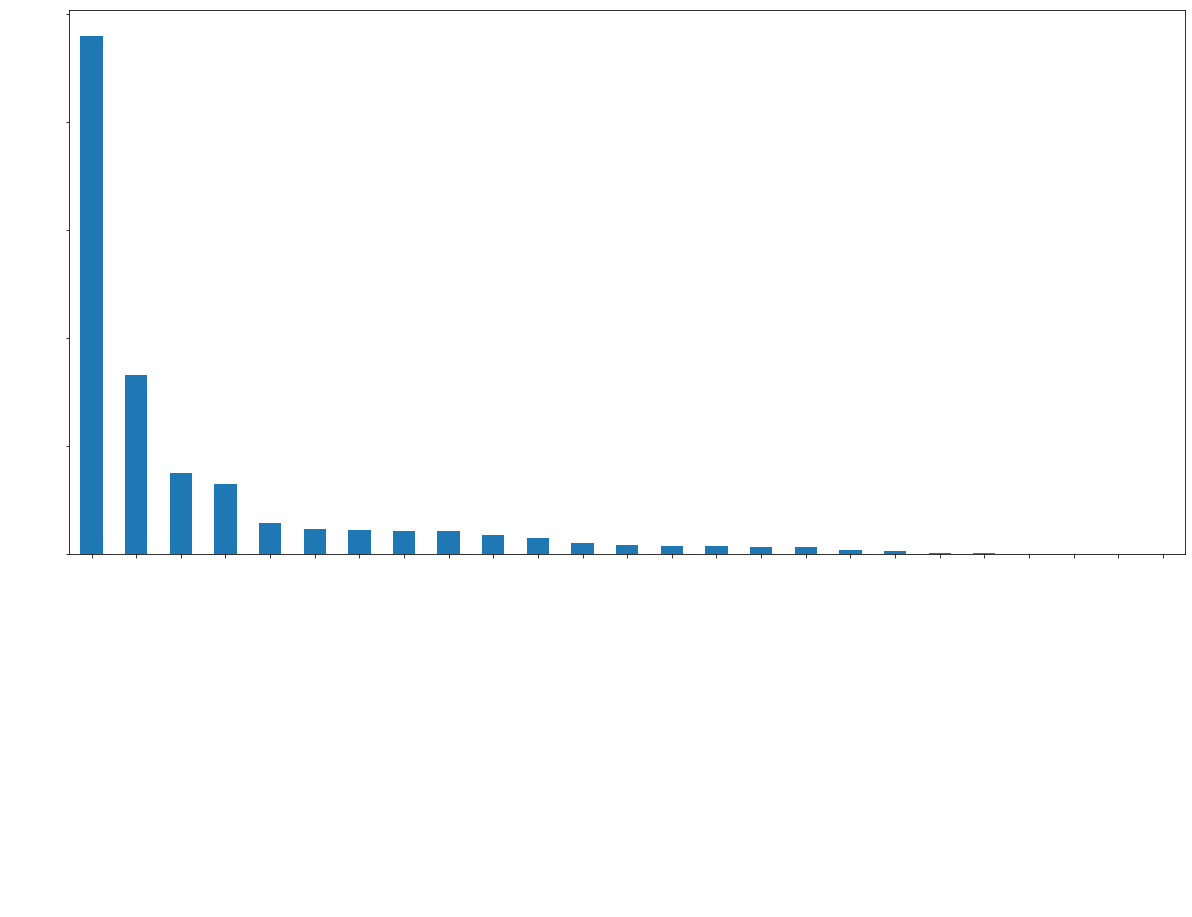

feature: {} 소업종
강선건조또는수리업           3314
자동차제조업              1504
자동차부분품제조업           1100
각종기계또는동부속품제조업       1090
기타금속제품제조업또는금속가공업    1035
                    ... 
담배재건조및담배제품제조업          1
금융업                    1
작물생산업                  1
메리야스제조업                1
전각항에해당하지않은사업           1
Name: 소업종, Length: 178, dtype: int64


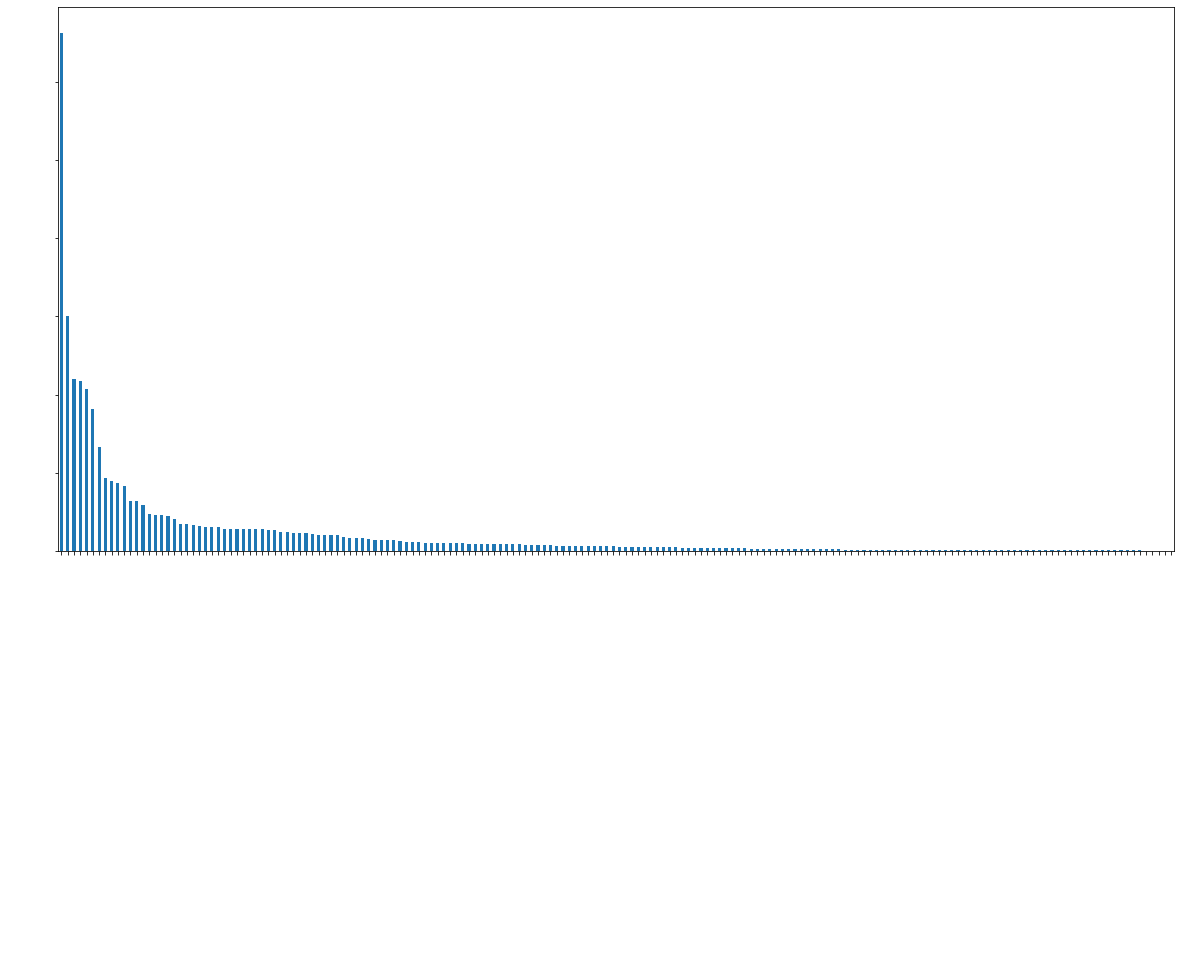

feature: {} 근로자수
12978    553
14284    497
12992    485
1        466
2        383
        ... 
737        1
400        1
243        1
503        1
382        1
Name: 근로자수, Length: 753, dtype: int64


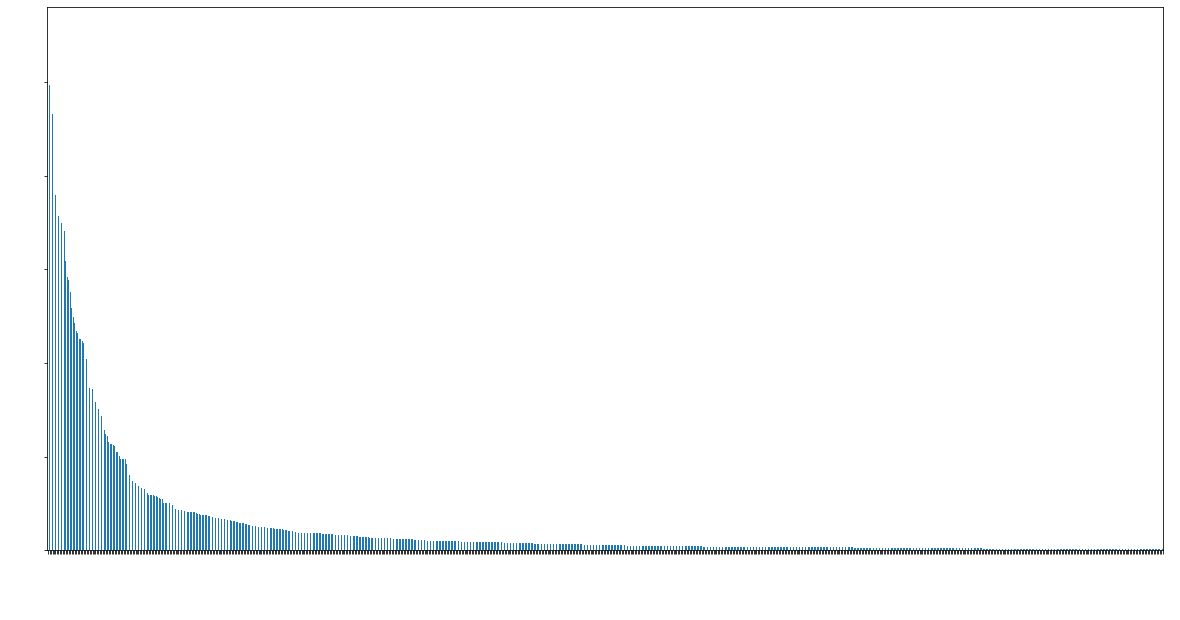

feature: {} 발생형태
끼임              4498
작업관련질병(뇌심 등)    3713
넘어짐             1920
직업병(진폐 제외)      1588
부딪힘             1524
물체에 맞음          1428
떨어짐             1199
절단·베임·찔림        1135
불균형 및 무리한동작      770
이상온도 접촉          443
깔림·뒤집힘           385
사업장외 교통사고        310
체육행사 등의 사고       274
화학물질누출·접촉        162
사업장내 교통사고        110
폭발·파열             87
감전                75
화재                57
진폐                49
폭력행위              40
무너짐               39
기타                 5
동물상해               5
분류불능               4
산소결핍               3
빠짐ㆍ익사              2
Name: 발생형태, dtype: int64


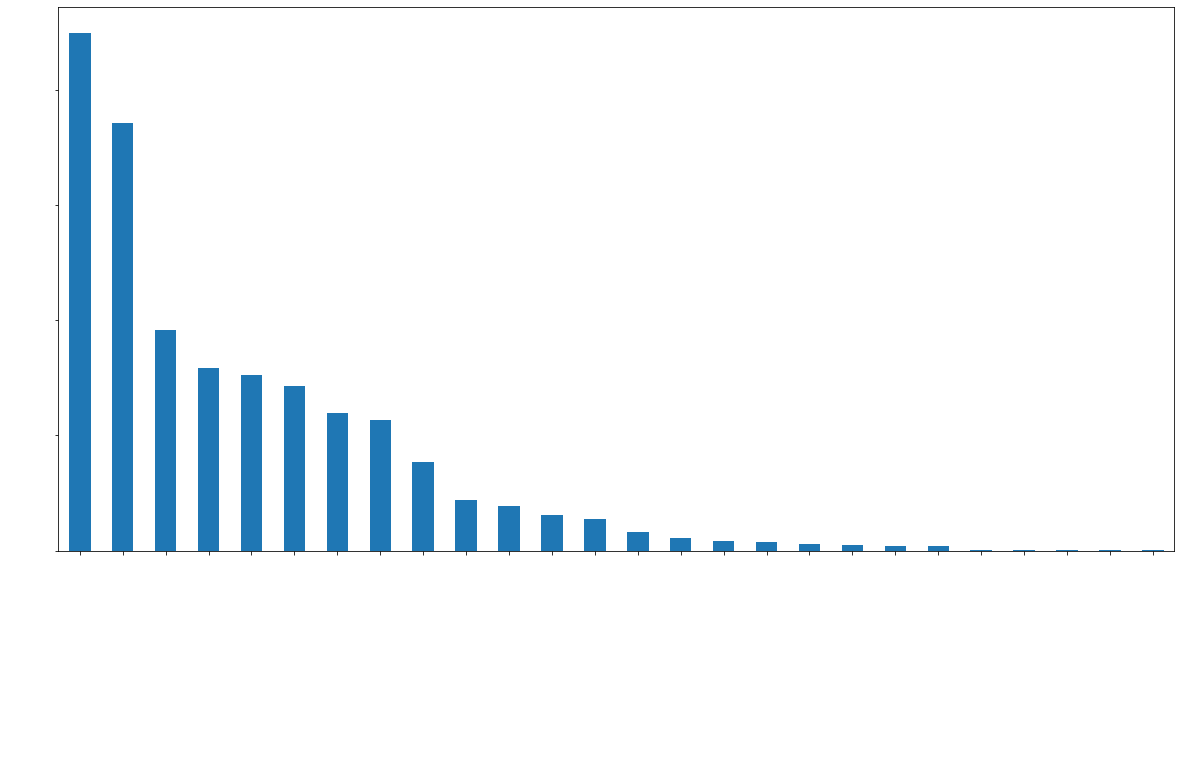

feature: {} 근속기간
20년 이상          4353
5년 ~ 10년 미만     2583
10년 ~ 20년 미만    2509
1년 ~ 2년 미만      1940
1개월 미만          1558
6개월 ~ 1년 미만     1476
2년 ~ 3년 미만      1376
3년 ~ 4년 미만       950
4년 ~ 5년 미만       753
1개월 ~ 2개월 미만     662
2개월 ~ 3개월 미만     508
3개월 ~ 4개월 미만     445
4개월 ~ 5개월 미만     366
5개월 ~ 6개월 미만     338
분류불능               8
Name: 근속기간, dtype: int64


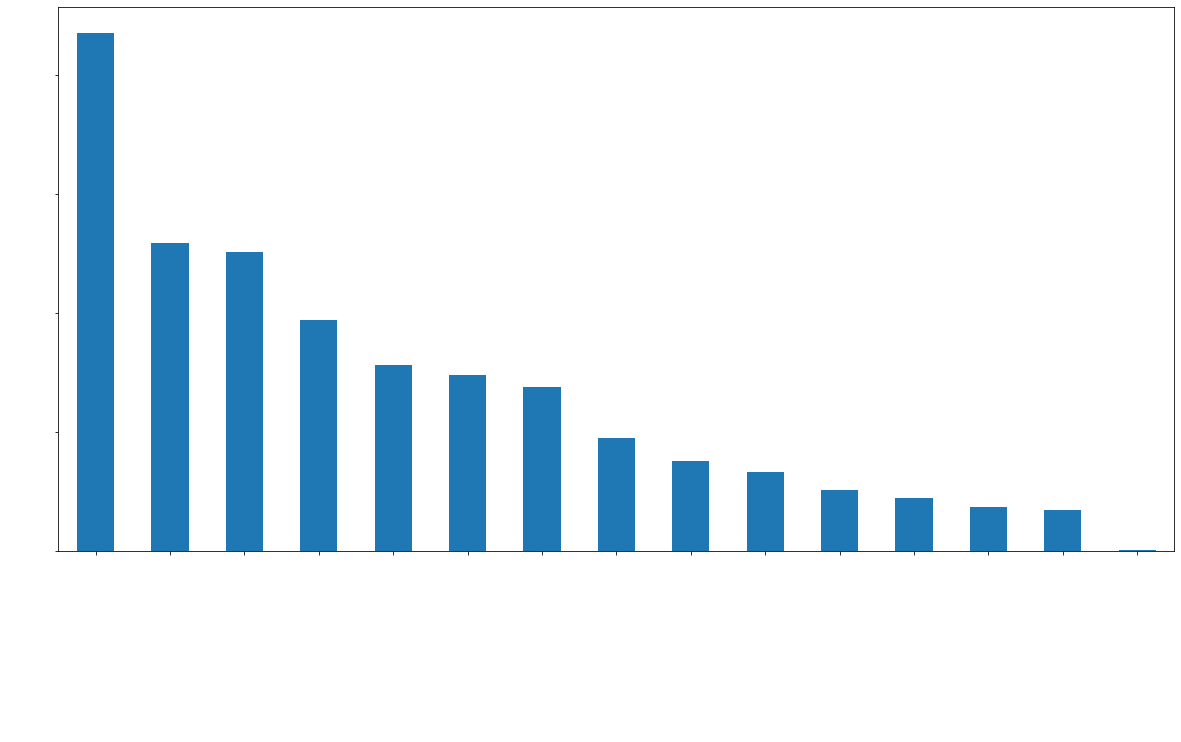

feature: {} 연령
60세 ~ 64세    3146
55세 ~ 59세    2881
50세 ~ 54세    2661
40세 ~ 44세    2329
45세 ~ 49세    2289
35세 ~ 39세    2012
30세 ~ 34세    1539
25세 ~ 29세    1299
65세 ~ 69세     734
18세 ~ 24세     589
70세 ~ 74세     244
75세 ~ 79세      85
80세 이상         17
Name: 연령, dtype: int64


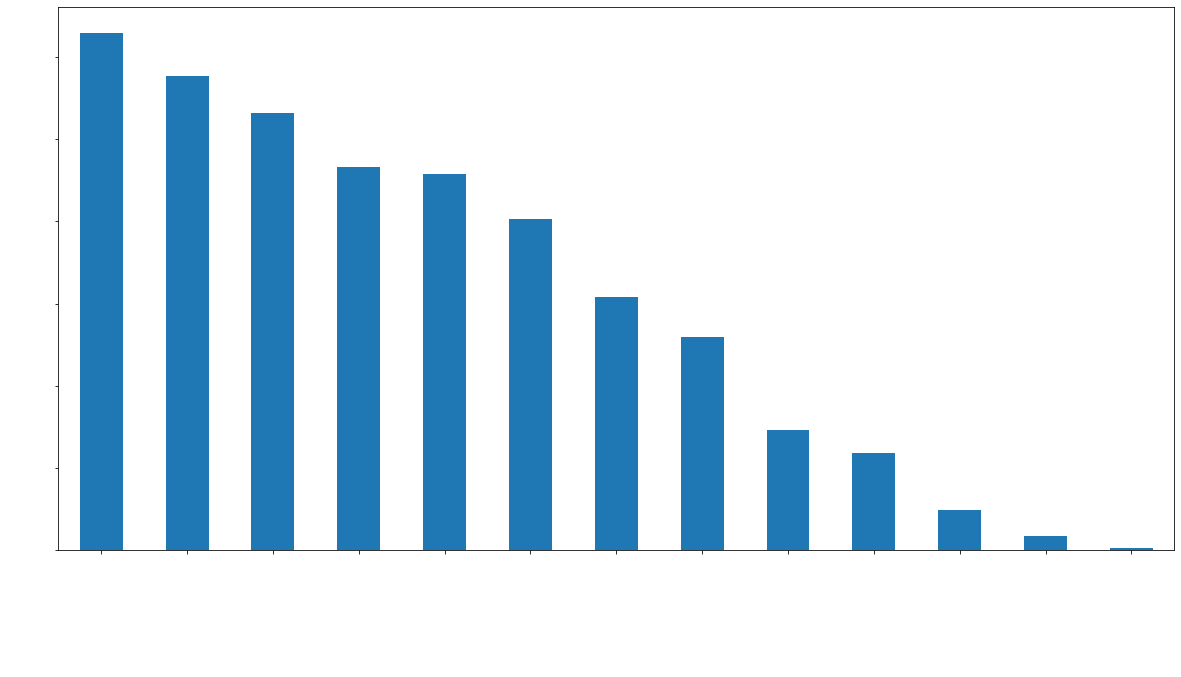

In [80]:
for i in data1.columns:  
  print('feature: {}', format(i))
  print(data1[i].value_counts())
  plt.figure(figsize = (20, 10))
  data1[i].value_counts().plot(kind = "bar")
  plt.tick_params(axis='y', labelcolor='white')
  plt.tick_params(axis='x', labelcolor='white')
  plt.show()

In [129]:
result_단지명 = le.fit_transform(data1["단지명"])
result_중업종 = le.fit_transform(data1["중업종"])
result_소업종 = le.fit_transform(data1["소업종"])
result_발생형태 = le.fit_transform(data1["발생형태"])
result_근속기간 = le.fit_transform(data1["근속기간"])
result_연령 = le.fit_transform(data1["연령"])
print(result_단지명)
print(result_중업종)
print(result_소업종)
print(result_발생형태)
print(result_근속기간)
print(result_연령)

[25 25 25 ... 33 33 33]
[ 7  7 21 ... 10 10 10]
[ 54  54 114 ...   6   6   6]
[21 21  4 ... 11  4  3]
[ 3 12 10 ...  0 12  0]
[2 6 7 ... 3 2 4]


In [82]:
data1.단지명 = result_단지명
data1.중업종 = result_중업종
data1.소업종 = result_소업종
data1.발생형태 = result_발생형태
data1.근속기간 = result_근속기간
data1.연령 = result_연령
data1.head()

,단지명,중업종,소업종,근로자수,발생형태,근속기간,연령
0,25,7,54,7,21,3,2
1,25,7,54,7,21,12,6
2,25,21,114,4,4,10,7
3,25,11,111,2,4,0,6
4,25,11,141,4,3,3,8


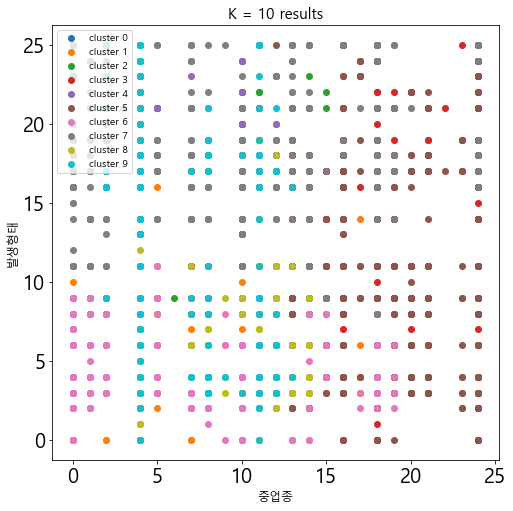

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize = (8, 8))

for i in range(k):
    plt.scatter(data1.loc[data1['cluster'] == i, '중업종'], data1.loc[data1['cluster'] == i, '발생형태'], 
                label = 'cluster ' + str(i))

plt.legend()
plt.title('K = %d results'%k , size = 15)
plt.xlabel('중업종', size = 12)
plt.ylabel('발생형태', size = 12)
plt.show()

In [86]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   단지명      19825 non-null  int32
 1   중업종      19825 non-null  int32
 2   소업종      19825 non-null  int32
 3   근로자수     19825 non-null  int64
 4   발생형태     19825 non-null  int32
 5   근속기간     19825 non-null  int32
 6   연령       19825 non-null  int32
 7   cluster  19825 non-null  int32
dtypes: int32(7), int64(1)
memory usage: 697.1 KB


In [87]:
data1.head()

,단지명,중업종,소업종,근로자수,발생형태,근속기간,연령,cluster
0,25,7,54,7,21,3,2,7
1,25,7,54,7,21,12,6,1
2,25,21,114,4,4,10,7,3
3,25,11,111,2,4,0,6,8
4,25,11,141,4,3,3,8,8


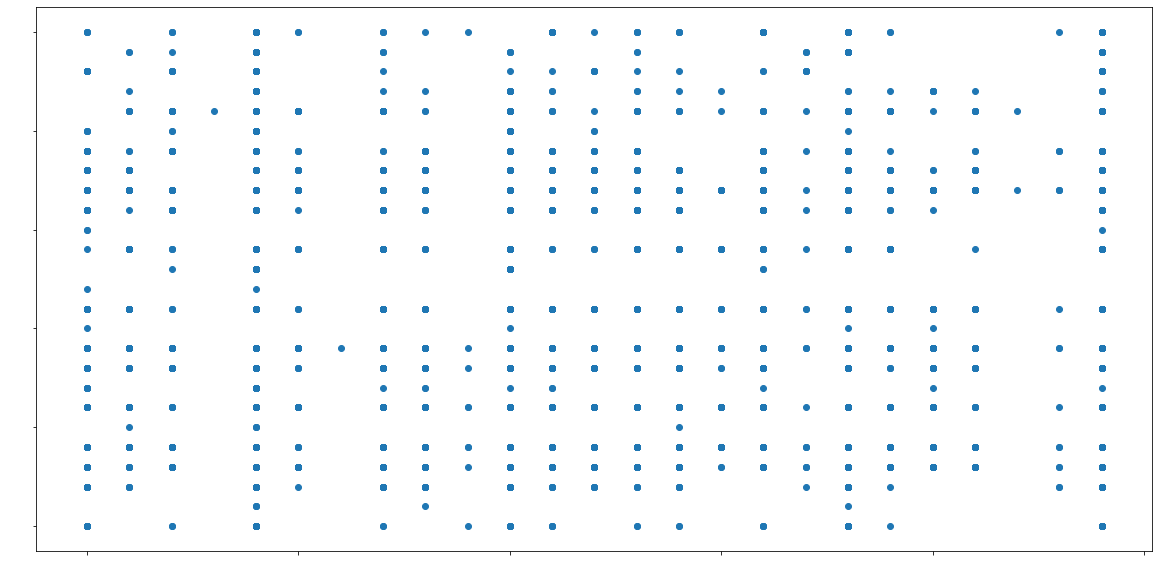

In [88]:
plt.figure(figsize = (20,10))
plt.scatter(data1.중업종, data1.발생형태)
plt.tick_params(axis='y', labelcolor='white')
plt.tick_params(axis='x', labelcolor='white')

In [90]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19825 entries, 0 to 19824
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   단지명      19825 non-null  int32
 1   중업종      19825 non-null  int32
 2   소업종      19825 non-null  int32
 3   근로자수     19825 non-null  int64
 4   발생형태     19825 non-null  int32
 5   근속기간     19825 non-null  int32
 6   연령       19825 non-null  int32
 7   cluster  19825 non-null  int32
dtypes: int32(7), int64(1)
memory usage: 697.1 KB


In [100]:
x = data1.drop(columns = ["발생형태", "소업종"])
y = data1.발생형태

In [101]:
x

,단지명,중업종,근로자수,근속기간,연령,cluster
0,25,7,7,3,2,7
1,25,7,7,12,6,1
2,25,21,4,10,7,3
3,25,11,2,0,6,8
4,25,11,4,3,8,8
...,...,...,...,...,...,...
19820,33,10,646,0,4,6
19821,33,10,721,0,5,7
19822,33,10,646,0,3,6
19823,33,10,646,12,2,1


In [102]:
x.drop(columns = "cluster", axis = 1, inplace = True)
x

,단지명,중업종,근로자수,근속기간,연령
0,25,7,7,3,2
1,25,7,7,12,6
2,25,21,4,10,7
3,25,11,2,0,6
4,25,11,4,3,8
...,...,...,...,...,...
19820,33,10,646,0,4
19821,33,10,721,0,5
19822,33,10,646,0,3
19823,33,10,646,12,2


In [103]:
y = pd.DataFrame(y)
y

,발생형태
0,21
1,21
2,4
3,4
4,3
...,...
19820,9
19821,19
19822,11
19823,4
